# SLy4 Mass-Radius Comparison

This notebook imports the SLy4 CompOSE EoS, computes a mass-radius relation with EOSeNS, and compares it with the downloaded CompOSE `eos.mr` reference data.

In [1]:
using Pkg

project_root = normpath(joinpath(@__DIR__, "..", ".."))
Pkg.activate(project_root)

using DelimitedFiles
using Plots

using EOSeNS.NEOS
using EOSeNS.TOV

plotlyjs()

  Activating project at `~/Desktop/GitRepositories/EOSeNS`


WebIO._IJuliaInit()

Plots.PlotlyJSBackend()

## Load SLy4 from CompOSE

In [2]:
sly4_path = joinpath(project_root, "data", "CompOSE", "SLy4")

sly4_eos = readComposeColdNS1dEos("SLy4")
sly4_eos

BarotropicEOS: SLy4
n_data: 197 
----------------|---------------------|---------------
Lables          :  min_val - max_val  :  Units 
----------------|---------------------|---------------
pressure        :  2.143e-08 - 863.8    :  MeV^1 / fm^3 
energy_density  :  9.308e-05 - 1607     :  MeV^1 / fm^3 
number_density  :    1e-07 - 1.21     :  1 / fm^3 


## Load CompOSE Mass-Radius Data

`eos.mr` columns are radius `[km]` and gravitational mass `[M_sol]`.

In [3]:
compose_mr_file = joinpath(sly4_path, "eos.mr")
compose_mr = Matrix{Float64}(readdlm(compose_mr_file; comments=true, comment_char='#'))

compose_radius = compose_mr[:, 1]
compose_mass = compose_mr[:, 2]

println("CompOSE points: ", length(compose_radius))
println("radius range: ", extrema(compose_radius), " km")
println("mass range: ", extrema(compose_mass), " M_sol")

CompOSE points: 56
radius range: (10.008100000018878, 11.915700000025817) km
mass range: (0.6978931915523003, 2.052280367269244) M_sol


## Compute Mass-Radius Relation with EOSeNS

In [4]:
eosens_mass, eosens_radius, central_pressure = getMassRadiusRelation(
    sly4_eos;
    n_points=length(compose_radius),
    pressure_min=1e34
)

println("EOSeNS points: ", length(eosens_radius))
println("radius range: ", extrema(eosens_radius), " km")
println("mass range: ", extrema(eosens_mass), " M_sol")

EOSeNS points: 75
radius range: (9.974803700662758, 12.739422634781908) km
mass range: (0.3383167892361459, 2.050514360931871) M_sol


## Compare Curves

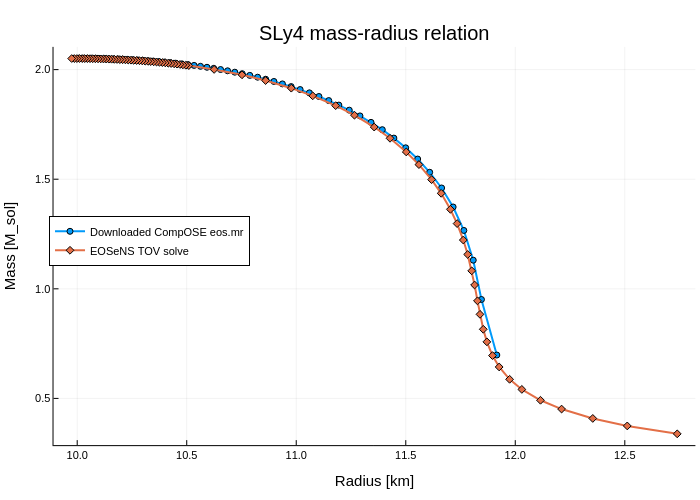

In [5]:
plot(compose_radius, compose_mass;
    label="Downloaded CompOSE eos.mr",
    xlabel="Radius [km]",
    ylabel="Mass [M_sol]",
    linewidth=2,
    marker=:circle,
    markersize=3,
    title="SLy4 mass-radius relation"
)

plot!(eosens_radius, eosens_mass;
    label="EOSeNS TOV solve",
    linewidth=2,
    marker=:diamond,
    markersize=3,
    legend=:left
)

## Simple Difference Diagnostic

Interpolate the EOSeNS curve onto the CompOSE radii over the shared radius range and plot the mass residual.

max |Delta M| over shared range: 0.0978923778938997 M_sol


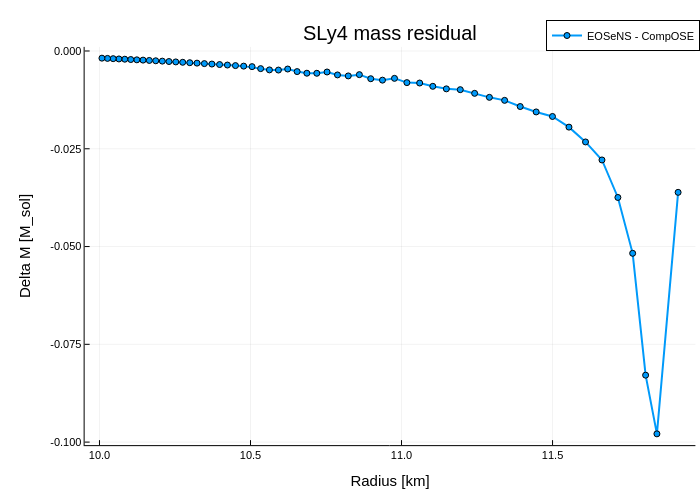

In [6]:
order = sortperm(eosens_radius)
r_sorted = eosens_radius[order]
m_sorted = eosens_mass[order]

shared = (compose_radius .>= minimum(r_sorted)) .& (compose_radius .<= maximum(r_sorted))
function interp_linear(x, y, xq)
    i = searchsortedlast(x, xq)
    i = clamp(i, 1, length(x) - 1)
    t = (xq - x[i]) / (x[i + 1] - x[i])
    return (1 - t) * y[i] + t * y[i + 1]
end

m_interp = [interp_linear(r_sorted, m_sorted, r) for r in compose_radius[shared]]
mass_residual = m_interp .- compose_mass[shared]

println("max |Delta M| over shared range: ", maximum(abs.(mass_residual)), " M_sol")

plot(compose_radius[shared], mass_residual;
    xlabel="Radius [km]",
    ylabel="Delta M [M_sol]",
    label="EOSeNS - CompOSE",
    linewidth=2,
    marker=:circle,
    markersize=3,
    title="SLy4 mass residual"
)